# 03 — Machine Learning: Model Training & Evaluation

**Project:** Insurance Fraud Detection  
**Input:** Processed feature sets from `02_Feature_Engineering.ipynb`  
**Goal:** Train, tune, and evaluate multiple classifiers to identify the best model for fraud detection.

---
## Table of Contents
1. [Setup & Data Import](#1)
2. [Baseline Models (Cross-Validation)](#2)
3. [Hyperparameter Tuning — GridSearchCV](#3)
4. [Best Model: Deep Evaluation](#4)
5. [Discussion & Next Steps](#5)

## 1. Setup & Data Import <a id='1'></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    cross_val_score, GridSearchCV, StratifiedKFold,
    train_test_split, cross_validate
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score, make_scorer
)
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

# Load feature sets
X_tree_df = pd.read_csv('../Dataset/Processed/X_tree.csv')
X_linear_df = pd.read_csv('../Dataset/Processed/X_linear_scaled.csv')
X_dist_df = pd.read_csv('../Dataset/Processed/X_dist_scaled.csv')

y_tree = X_tree_df['fraud_reported']
y_linear = X_linear_df['fraud_reported']
y_dist = X_dist_df['fraud_reported']

X_tree = X_tree_df.drop(columns=['fraud_reported'])
X_linear = X_linear_df.drop(columns=['fraud_reported'])
X_dist = X_dist_df.drop(columns=['fraud_reported'])

print(f"X_tree: {X_tree.shape}, X_linear: {X_linear.shape}, X_dist: {X_dist.shape}")
print(f"Fraud rate: {y_dist.mean():.2%}")

X_tree: (980, 71), X_linear: (980, 37), X_dist: (980, 28)
Fraud rate: 24.59%


## 2. Baseline Models — Cross-Validation <a id='2'></a>

Before tuning, we run each model with default parameters and 5-fold stratified cross-validation to get a baseline.

In [37]:
# Models to evaluate
models_baseline = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM':                 SVC(class_weight='balanced'),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost':             xgb.XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=3)
}

scoring = {
    'roc_auc': 'roc_auc',
    'f1': make_scorer(f1_score, pos_label=1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_sets = {
    'Tree based':     (X_tree, y_tree),
    'Linear':         (X_linear, y_linear),
    'Distance based': (X_dist, y_dist)
}

baseline_results = []
for fs_name, (X_fs, y_fs) in feature_sets.items():
    for model_name, clf in models_baseline.items():
        if (
            (model_name in ['Decision Tree', 'Random Forest', 'XGBoost']
                and fs_name in ['Tree based', 'Linear', 'Distance based'])
            or (model_name in ['Logistic Regression', 'SVM']
                and fs_name in ['Linear', 'Distance based'])
            or (model_name == 'KNN'
                and fs_name == 'Distance based')
        ):
            cv_results = cross_validate(clf, X_fs, y_fs, cv=cv, scoring=scoring)
            baseline_results.append({
                'Feature Set':    fs_name,
                'Model':          model_name,
                'CV ROC AUC':     cv_results['test_roc_auc'].mean().round(4),
                'CV F1':          cv_results['test_f1'].mean().round(4),
                'ROC AUC std':    cv_results['test_roc_auc'].std().round(4),
                'F1 std':         cv_results['test_f1'].std().round(4)
            })
            print(f"{fs_name} | {model_name}: "
                  f"ROC AUC {cv_results['test_roc_auc'].mean():.4f} (+/-) {cv_results['test_roc_auc'].std():.4f} | "
                  f"F1 {cv_results['test_f1'].mean():.4f} (+/-) {cv_results['test_f1'].std():.4f}")

df_baseline = pd.DataFrame(baseline_results)
df_baseline.sort_values('CV F1', ascending=False)

Tree based | Decision Tree: ROC AUC 0.6172 (+/-) 0.0461 | F1 0.4193 (+/-) 0.0721
Tree based | Random Forest: ROC AUC 0.7541 (+/-) 0.0492 | F1 0.1096 (+/-) 0.0485
Tree based | XGBoost: ROC AUC 0.7557 (+/-) 0.0416 | F1 0.5113 (+/-) 0.0588
Linear | Logistic Regression: ROC AUC 0.7919 (+/-) 0.0454 | F1 0.6094 (+/-) 0.0665
Linear | SVM: ROC AUC 0.7753 (+/-) 0.0552 | F1 0.6197 (+/-) 0.0792
Linear | Decision Tree: ROC AUC 0.6167 (+/-) 0.0506 | F1 0.4181 (+/-) 0.0873
Linear | Random Forest: ROC AUC 0.7742 (+/-) 0.0375 | F1 0.2993 (+/-) 0.0606
Linear | XGBoost: ROC AUC 0.7591 (+/-) 0.0425 | F1 0.5113 (+/-) 0.0809
Distance based | Logistic Regression: ROC AUC 0.7913 (+/-) 0.0509 | F1 0.6160 (+/-) 0.0625
Distance based | SVM: ROC AUC 0.7811 (+/-) 0.0494 | F1 0.6312 (+/-) 0.0672
Distance based | KNN: ROC AUC 0.6895 (+/-) 0.0514 | F1 0.3798 (+/-) 0.0705
Distance based | Decision Tree: ROC AUC 0.6003 (+/-) 0.0242 | F1 0.3951 (+/-) 0.0456
Distance based | Random Forest: ROC AUC 0.7819 (+/-) 0.0429 | 

,Feature Set,Model,CV ROC AUC,CV F1,ROC AUC std,F1 std
9,Distance based,SVM,0.7811,0.6312,0.0494,0.0672
4,Linear,SVM,0.7753,0.6197,0.0552,0.0792
8,Distance based,Logistic Regression,0.7913,0.6160,0.0509,0.0625
3,Linear,Logistic Regression,0.7919,0.6094,0.0454,0.0665
2,Tree based,XGBoost,0.7557,0.5113,0.0416,0.0588
7,Linear,XGBoost,0.7591,0.5113,0.0425,0.0809
13,Distance based,XGBoost,0.7624,0.5013,0.0515,0.0471
0,Tree based,Decision Tree,0.6172,0.4193,0.0461,0.0721
5,Linear,Decision Tree,0.6167,0.4181,0.0506,0.0873
11,Distance based,Decision Tree,0.6003,0.3951,0.0242,0.0456


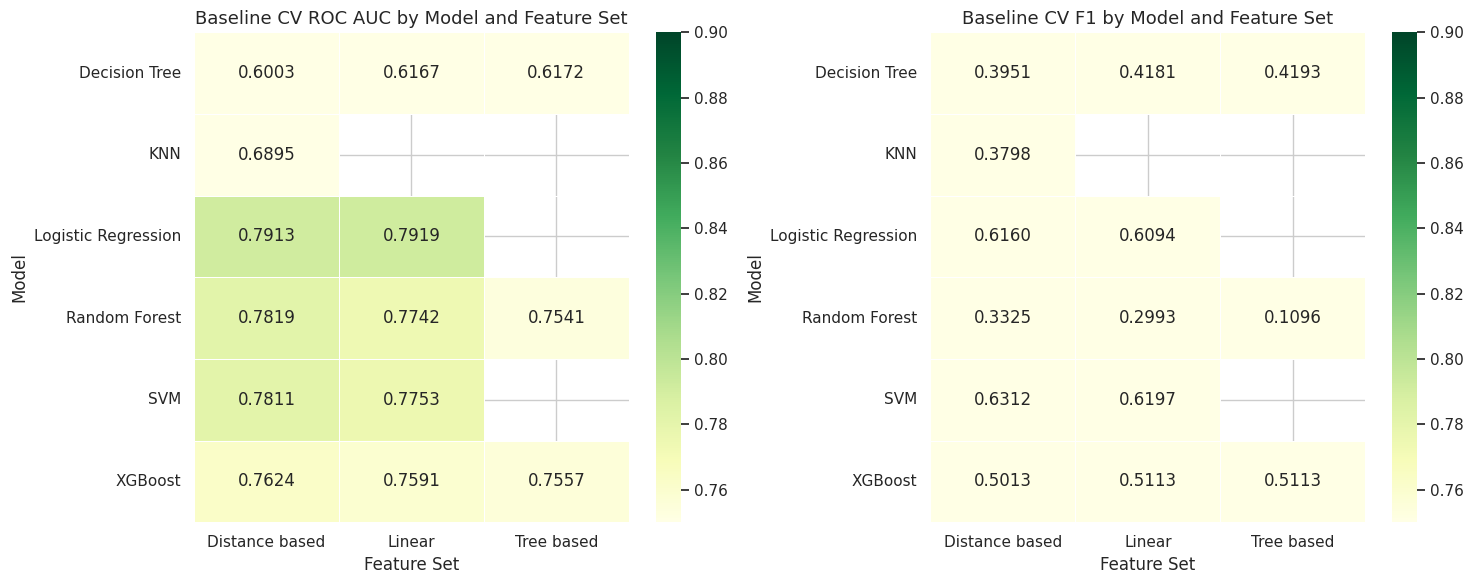

In [38]:
# Heatmap of baseline results
pivot_ROC = df_baseline.pivot(index='Model', columns='Feature Set', values='CV ROC AUC')
pivot_F1 = df_baseline.pivot(index='Model', columns='Feature Set', values='CV F1')

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(pivot_ROC, annot=True, fmt='.4f', cmap='YlGn', linewidths=0.5, vmin=0.75, vmax=0.90, ax=axs[0])
sns.heatmap(pivot_F1, annot=True, fmt='.4f', cmap='YlGn', linewidths=0.5, vmin=0.75, vmax=0.90, ax=axs[1])
axs[0].set_title('Baseline CV ROC AUC by Model and Feature Set', fontsize=13)
axs[1].set_title('Baseline CV F1 by Model and Feature Set', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning — GridSearchCV <a id='3'></a>

In [39]:
# Parameter grids
param_grids = [
    {
        'model': 'Logistic Regression',
        'classifier': LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2']
        }
    },
    {
        'model': 'SVM',
        'classifier': SVC(probability=True, class_weight='balanced'),
        'params': [
            {'C': [0.01, 0.1, 1], 'kernel': ['linear']},
            {'C': [0.1, 1, 10],   'kernel': ['rbf'], 'gamma': ['scale', 'auto']}
        ]
    },
    {
        'model': 'KNN',
        'classifier': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [5, 7, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    {
        'model': 'Decision Tree',
        'classifier': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'max_depth': [3, 4, 5, 7],
            'min_samples_leaf': [5, 10, 20]
        }
    },
    {
        'model': 'Random Forest',
        'classifier': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15],
            'max_features': ['sqrt', 0.3]
        }
    },
    {
        'model': 'XGBoost',
        'classifier': xgb.XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=3),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.01, 0.05, 0.1],
            'colsample_bytree': [0.7, 1.0]    # Randomly drops features per tree, reduces overfit
        }
    }
]
print(f"{len(param_grids)} models to tune")

6 models to tune


In [40]:
# Run GridSearchCV across all models and feature sets
tuning_results = []

for fs_name, (X_fs, y_fs) in feature_sets.items():
    print(f"\n--- Feature Set: {fs_name} ---")
    for entry in param_grids:
        if (
            (entry['model'] in ['Decision Tree', 'Random Forest', 'XGBoost']
                and fs_name in ['Tree based', 'Linear', 'Distance based'])
            or (entry['model'] in ['Logistic Regression', 'SVM']
                and fs_name in ['Linear', 'Distance based'])
            or (entry['model'] == 'KNN'
                and fs_name == 'Distance based')
        ):
            gs = GridSearchCV(
                entry['classifier'], entry['params'],
                cv=cv,
                scoring=scoring,
                refit='f1',
                n_jobs=-1
            )
            gs.fit(X_fs, y_fs)
            tuning_results.append({
                'Feature Set': fs_name,
                'Model': entry['model'],
                'Best Params': gs.best_params_,
                'CV ROC AUC': round(gs.cv_results_['mean_test_roc_auc'][gs.best_index_], 4),
                'CV F1': round(gs.cv_results_['mean_test_f1'][gs.best_index_], 4),
                'Best Estimator': gs.best_estimator_
            })
            print(f"{entry['model']}: ROC-AUC {gs.cv_results_['mean_test_roc_auc'][gs.best_index_]:.4f} | F1 {gs.cv_results_['mean_test_f1'][gs.best_index_]:.4f} | {gs.best_params_}")

df_tuning = pd.DataFrame(tuning_results)
print("\nGridSearchCV complete")


--- Feature Set: Tree based ---
Decision Tree: ROC-AUC 0.7921 | F1 0.6270 | {'max_depth': 3, 'min_samples_leaf': 10}
Random Forest: ROC-AUC 0.7773 | F1 0.6295 | {'max_depth': 5, 'max_features': 0.3, 'n_estimators': 300}
XGBoost: ROC-AUC 0.7702 | F1 0.6344 | {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- Feature Set: Linear ---
Logistic Regression: ROC-AUC 0.7878 | F1 0.6274 | {'C': 0.1, 'penalty': 'l1'}
SVM: ROC-AUC 0.7934 | F1 0.6380 | {'C': 0.01, 'kernel': 'linear'}
Decision Tree: ROC-AUC 0.7874 | F1 0.6346 | {'max_depth': 3, 'min_samples_leaf': 5}
Random Forest: ROC-AUC 0.7861 | F1 0.6318 | {'max_depth': 5, 'max_features': 0.3, 'n_estimators': 200}
XGBoost: ROC-AUC 0.7778 | F1 0.6344 | {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- Feature Set: Distance based ---
Logistic Regression: ROC-AUC 0.7893 | F1 0.6302 | {'C': 0.1, 'penalty': 'l1'}
SVM: ROC-AUC 0.7847 | F1 0.6380 | {'C': 0.01, 'kernel': 

## 4. Best Models: Deep Evaluation <a id='4'></a>

In [48]:
# Select top 3 best feature set and model for deep evaluation
i=0
best_entry = df_tuning.sort_values('CV F1', ascending=False).head(3)
fs_map = {'Tree based': (X_tree, y_tree), 'Linear': (X_linear, y_linear), 'Distance based': (X_dist, y_dist)}

print("Classification Reports for best models:\n")

for _, entry in best_entry.iterrows():
  X_best, y_best = fs_map[entry['Feature Set']]
  best_clf = entry['Best Estimator']

  # Train/test split for a proper holdout evaluation
  X_train, X_test, y_train, y_test = train_test_split(
      X_best, y_best, test_size=0.2, random_state=42, stratify=y_best
  )
  best_clf.fit(X_train, y_train)
  y_pred = best_clf.predict(X_test)

  i=i+1
  print(f"--- TOP {i} Model ---")
  print(f"  Model:       {entry['Model']}")
  print(f"  Feature Set: {entry['Feature Set']}")
  print(f"  CV ROC AUC:  {entry['CV ROC AUC']}")
  print(f"  CV F1:       {entry['CV F1']}")
  print(f"  Params:      {entry['Best Params']}")
  print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Classification Reports for best models:
--- TOP 1 Model ---
  Model:       XGBoost
  Feature Set: Distance based
  CV ROC AUC:  0.7786
  CV F1:       0.638
  Params:      {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
              precision    recall  f1-score   support

  Legitimate       0.87      0.87      0.87       148
       Fraud       0.60      0.60      0.60        48

    accuracy                           0.81       196
   macro avg       0.74      0.74      0.74       196
weighted avg       0.81      0.81      0.81       196

--- TOP 2 Model ---
  Model:       SVM
  Feature Set: Linear
  CV ROC AUC:  0.7934
  CV F1:       0.638
  Params:      {'C': 0.01, 'kernel': 'linear'}
              precision    recall  f1-score   support

  Legitimate       0.87      0.88      0.88       148
       Fraud       0.62      0.60      0.61        48

    accuracy                           0.81       196
   macro avg       0.74      0.74      0.74    

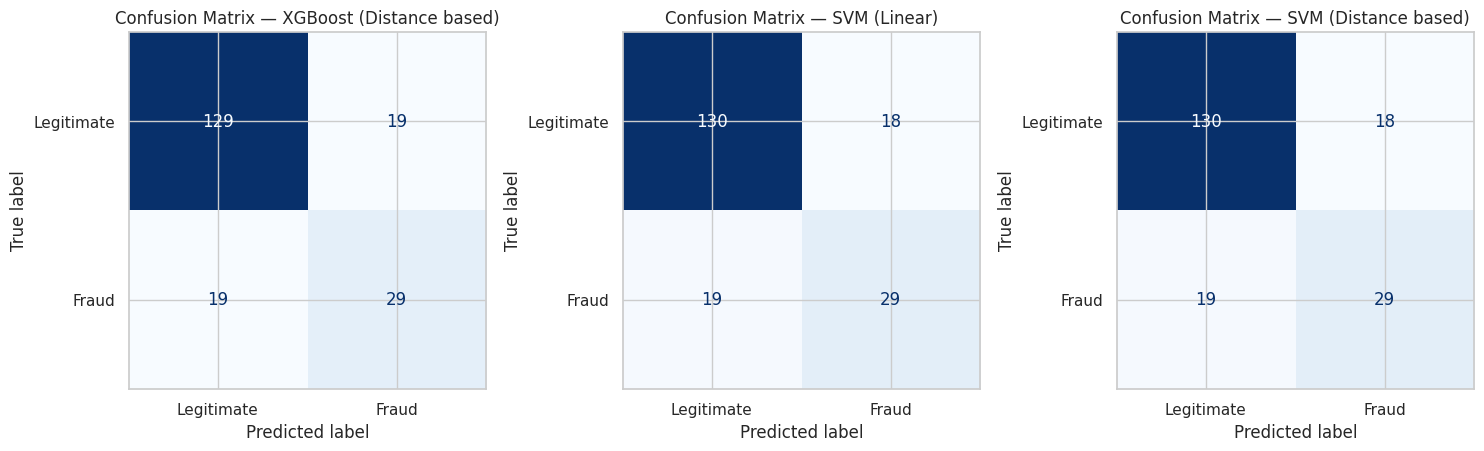

In [49]:
# Confusion Matrix
i=0
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for _, entry in best_entry.iterrows():
  X_best, y_best = fs_map[entry['Feature Set']]
  best_clf = entry['Best Estimator']

  # Train/test split for a proper holdout evaluation
  X_train, X_test, y_train, y_test = train_test_split(
      X_best, y_best, test_size=0.2, random_state=42, stratify=y_best
  )
  best_clf.fit(X_train, y_train)
  y_pred = best_clf.predict(X_test)

  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
  disp.plot(ax=ax[i], cmap='Blues', colorbar=False)
  ax[i].set_title(f"Confusion Matrix — {entry['Model']} ({entry['Feature Set']})", fontsize=12)
  i=i+1

plt.tight_layout()
plt.show()

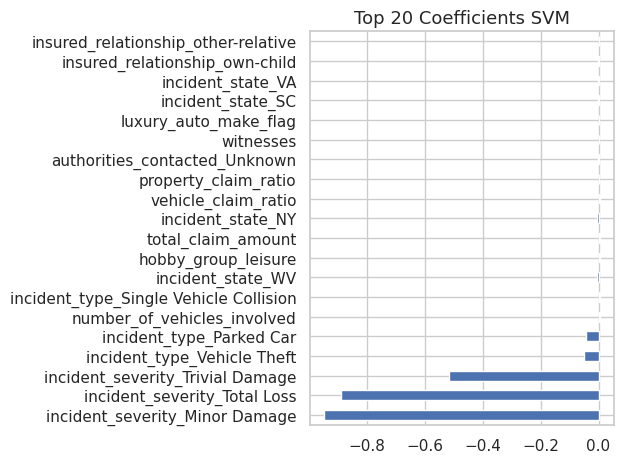

In [67]:
# Feature importance for TOP 2 Model
# We chose the simplest model given the close performance of the TOP 3
fs_name = best_entry['Feature Set'].iloc[1]

if 'Tree based' in fs_name:
  col_names = X_tree.columns
elif 'Linear' in fs_name:
  col_names = X_linear.columns
else:
  col_names = X_dist.columns

X_best, y_best = fs_map[fs_name]
best_clf = best_entry['Best Estimator'].iloc[1]

# Train/test split for a proper holdout evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y_best, test_size=0.2, random_state=42, stratify=y_best
)
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

if hasattr(best_clf, 'feature_importances_'):
    importances = pd.Series(best_clf.feature_importances_, index=col_names)
    importances = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    importances.plot(kind='barh', color='skyblue')
    plt.title('Top 20 Feature Importances', fontsize=13)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

elif hasattr(best_clf, 'coef_'):
    coefs = pd.Series(best_clf.coef_[0], index=col_names).sort_values(key=abs, ascending=False).head(20)
    coefs.plot(kind='barh')
    plt.title('Top 20 Coefficients SVM', fontsize=13)
    plt.tight_layout()
    plt.show()

else:
    print(f"Feature importance not directly available for {best_entry['Model'].iloc[1]}.")

## 5. Discussion & Next Steps <a id='5'></a>

### Results Summary

After testing 6 models across 3 feature sets, **SVM with a linear kernel on
the 37-feature set** came out on top; not by a huge margin, but consistently.

On the test set, it caught **60% of actual fraud cases** with **62% precision**,
for an overall **accuracy of 81%**.

### Key Takeaways

Tree-based models performed better on the 28 and 37 feature sets than on the full 71.

The features that mattered most were related to data about `incident_severity` and `incident_type`.
Fraud is about **how a claim is filed**, not who files it.

KNN didn't work. It predicted everyone as legitimate in its worst run.

### Limitations

- 980 rows is a small dataset
- Random train/test split doesn't simulate real deployment
- Threshold wasn't tuned, recall could improve with a lower one but we first need a answer to the business question ***What's more costly: missing a fraud or wrongly flagging a legitimate claim ?***

### Next Steps

The most useful thing to do next would be **threshold tuning**. Lowering the
decision threshold would catch more fraud at the cost of more false flags, and
finding the right trade-off depends on what's more expensive operationally.

After that, SMOTE for resampling and more data would likely be the biggest
performance levers.
